In [7]:
import os
import json
import pandas as pd
import torch
from glob import glob
import matplotlib.pyplot as plt

def extract_training_history():
    """
    Extract training history from checkpoint files and save to CSV/JSON.
    Returns a pandas DataFrame with the training history.
    """
    # Get all checkpoint files
    checkpoint_files = sorted(glob(os.path.join('checkpoints', 'checkpoint_epoch_*.pth')), 
                            key=lambda x: int(x.split('_')[-1].split('.')[0]))
    
    history = []
    
    for checkpoint_file in checkpoint_files:
        try:
            # Load checkpoint
            checkpoint = torch.load(checkpoint_file, map_location='cpu')
            
            # Extract training stats
            stats = checkpoint['training_stats']
            history.append({
                'epoch': stats['epoch'] + 1,  # Convert to 1-based indexing
                'train_loss': stats['train_loss'],
                'train_top1_acc': stats['train_top1_acc'],
                'train_top5_acc': stats['train_top5_acc'],
                'val_loss': stats['val_loss'],
                'val_top1_acc': stats['val_top1_acc'],
                'val_top5_acc': stats['val_top5_acc'],
                'learning_rate': stats['learning_rate']
            })
        except Exception as e:
            print(f"Error loading checkpoint {checkpoint_file}: {str(e)}")
    
    # Convert to DataFrame
    df = pd.DataFrame(history)
    
    # Save to CSV
    df.to_csv('training_history.csv', index=False)
    
    # Save to JSON with readable formatting
    with open('training_history.json', 'w') as f:
        json.dump(history, f, indent=4)
    
    print(f"Training history saved to training_history.csv and training_history.json")
    print("\nSummary of training:")
    print(f"Total epochs: {len(history)}")
    if len(history) > 0:
        print("\nTop-1 Accuracy:")
        print(f"Best validation accuracy: {max(df['val_top1_acc']):.2f}%")
        print(f"Final training accuracy: {df['train_top1_acc'].iloc[-1]:.2f}%")
        print(f"Final validation accuracy: {df['val_top1_acc'].iloc[-1]:.2f}%")
        
        print("\nTop-5 Accuracy:")
        print(f"Best validation accuracy: {max(df['val_top5_acc']):.2f}%")
        print(f"Final training accuracy: {df['train_top5_acc'].iloc[-1]:.2f}%")
        print(f"Final validation accuracy: {df['val_top5_acc'].iloc[-1]:.2f}%")
    
    return df

# Extract and plot the training history
if __name__ == "__main__":
    df = extract_training_history()

C:\Users\luqma\AppData\Local\Temp\ipykernel_1652\2838157785.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_file, map_location='cpu')

Training history saved to training_history.csv and training_history.json

Summary of training:
Total epochs: 100

Top-1 Accuracy:
Best validation accuracy: 71.46%
Final training accuracy: 78.03%
Final validation accuracy: 70.59%

Top-5 Accuracy:
Best validation accuracy: 91.09%
Final training accuracy: 91.23%
Final validation accuracy: 91.09%


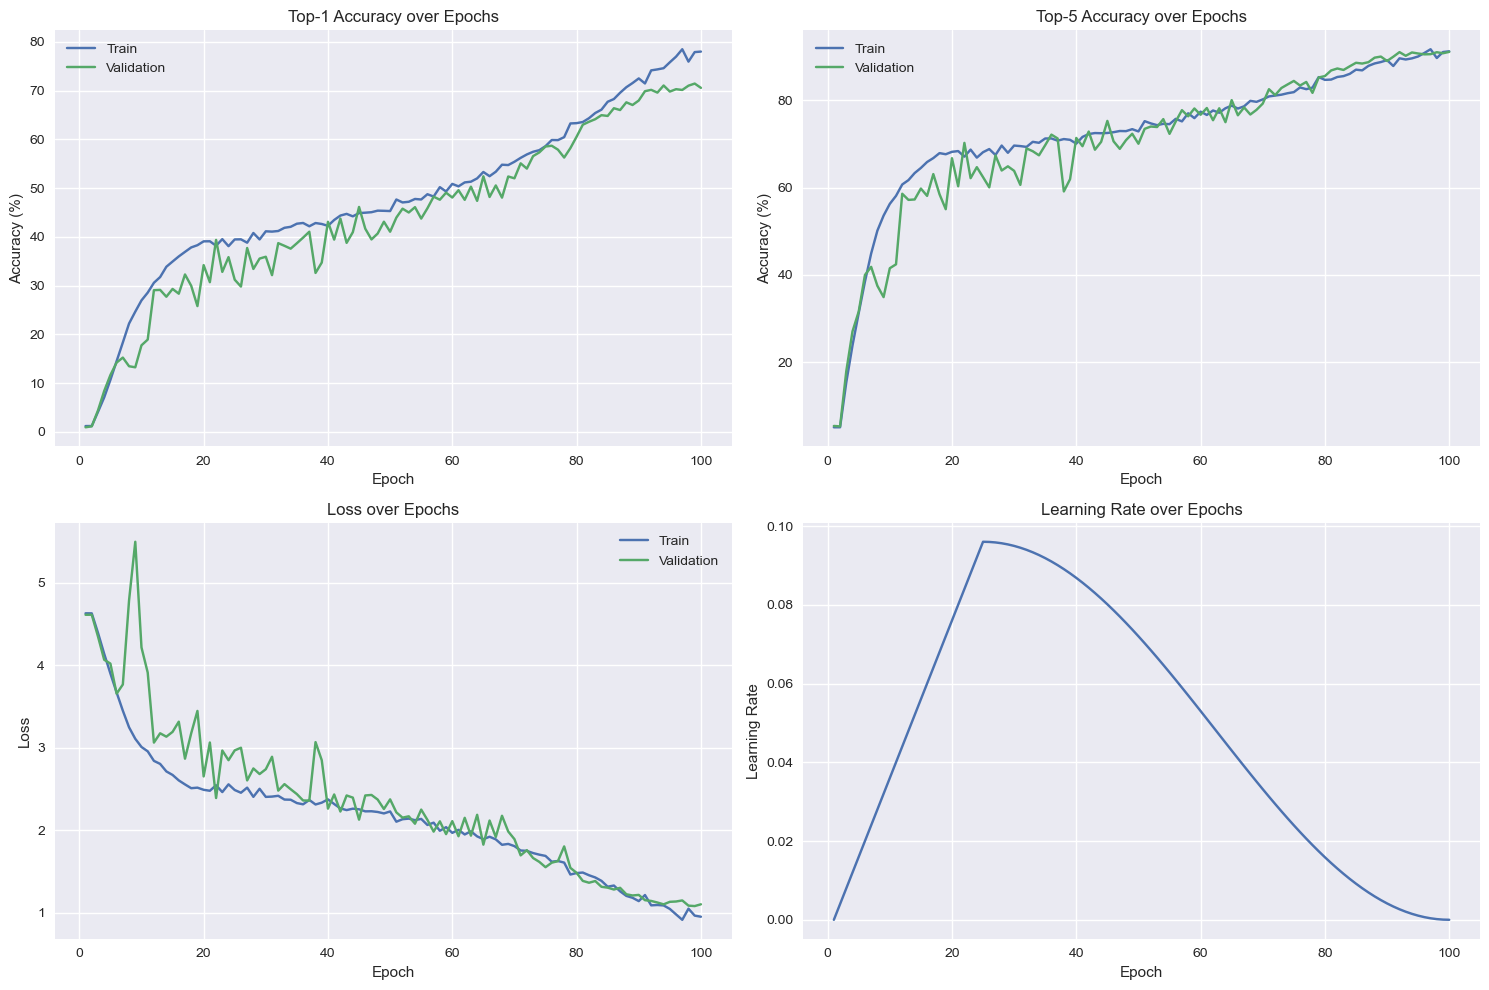

In [8]:
def plot_training_history(df, save_individual=True):
    """
    Plot training metrics both individually and combined.
    Args:
        df: DataFrame with training history
        save_individual: Whether to save individual plots
    """
    os.makedirs('plots', exist_ok=True)
    plt.style.use('seaborn-v0_8')
    
    metrics = [
        ('top1_accuracy', 'Top-1 Accuracy over Epochs', 'Accuracy (%)', 
         [('train_top1_acc', 'Train'), ('val_top1_acc', 'Validation')]),
        ('top5_accuracy', 'Top-5 Accuracy over Epochs', 'Accuracy (%)', 
         [('train_top5_acc', 'Train'), ('val_top5_acc', 'Validation')]),
        ('loss', 'Loss over Epochs', 'Loss', 
         [('train_loss', 'Train'), ('val_loss', 'Validation')]),
        ('learning_rate', 'Learning Rate over Epochs', 'Learning Rate', 
         [('learning_rate', None)])
    ]
    
    # Create combined plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()
    
    for idx, (name, title, ylabel, data_cols) in enumerate(metrics):
        # Plot individual
        if save_individual:
            plt.figure(figsize=(10, 6))
            for col, label in data_cols:
                plt.plot(df['epoch'], df[col], label=label, marker='+')
            plt.title(title)
            plt.xlabel('Epoch')
            plt.ylabel(ylabel)
            if len(data_cols) > 1:
                plt.legend()
            plt.grid(True)
            plt.savefig(f'plots/{name}.png', dpi=300, bbox_inches='tight')
            plt.close()
        
        # Plot on combined figure
        for col, label in data_cols:
            axes[idx].plot(df['epoch'], df[col], label=label, marker='+')
        axes[idx].set_title(title)
        axes[idx].set_xlabel('Epoch')
        axes[idx].set_ylabel(ylabel)
        if len(data_cols) > 1:
            axes[idx].legend()
        axes[idx].grid(True)
    
    plt.tight_layout()
    plt.savefig('plots/training_history_combined.png', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_training_history(df)